In [1]:
from google.colab import files
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv.zip to Womens Clothing E-Commerce Reviews.csv.zip


In [2]:
import pandas as pd

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv.zip")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk

In [4]:
df.shape

(23486, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
df.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [9]:
df.dropna(
    subset=[
        'Review Text',
        'Division Name',
        'Department Name',
        'Class Name'
    ],
    inplace=True
)

In [10]:
df.reset_index(drop=True, inplace=True)

In [11]:
df.isnull().sum()

,0
Clothing ID,0
Age,0
Title,2966
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,0
Department Name,0
Class Name,0


In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [16]:
df.shape

(22627, 10)

In [17]:
df_clean = df.copy()

In [18]:
df_clean['Review Text'] = df_clean['Review Text'].astype(str)

In [19]:
df_clean['Review Text'] = df_clean['Review Text'].str.lower()

In [20]:
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [21]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [22]:
def remove_url(text):
    return re.sub(r'http\S+|www\S+','',text)

df['Review Text'] = df['Review Text'].apply(remove_url)

In [23]:
def remove_html(text):
    return re.sub(r'<.*?>','',text)

df['Review Text'] = df['Review Text'].apply(remove_html)

In [24]:
def remove_numbers(text):
    return re.sub(r'\d+','',text)

df['Review Text'] = df['Review Text'].apply(remove_numbers)

In [25]:
def remove_punctuation(text):
    return text.translate(str.maketrans('','',string.punctuation))

df['Review Text'] = df['Review Text'].apply(remove_punctuation)

In [26]:
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['Review Text'] = df['Review Text'].apply(remove_emoji)

In [27]:
def remove_spaces(text):
    return " ".join(text.split())

df['Review Text'] = df['Review Text'].apply(remove_spaces)

In [28]:
df['Tokens'] = df['Review Text'].apply(word_tokenize)

In [29]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [30]:
df[['Review Text','Tokens']].head()

,Review Text,Tokens
0,Absolutely wonderful silky and sexy and comfor...,"[Absolutely, wonderful, silky, and, sexy, and,..."
1,Love this dress its sooo pretty i happened to ...,"[Love, this, dress, its, sooo, pretty, i, happ..."
2,I had such high hopes for this dress and reall...,"[I, had, such, high, hopes, for, this, dress, ..."
3,I love love love this jumpsuit its fun flirty ...,"[I, love, love, love, this, jumpsuit, its, fun..."
4,This shirt is very flattering to all due to th...,"[This, shirt, is, very, flattering, to, all, d..."


In [31]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['Tokens'] = df['Tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [32]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Tokens'] = df['Tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

In [33]:
df['Clean_Review'] = df['Tokens'].apply(lambda x: " ".join(x))

In [34]:
df[['Review Text', 'Tokens', 'Clean_Review']].head()

,Review Text,Tokens,Clean_Review
0,Absolutely wonderful silky and sexy and comfor...,"[Absolutely, wonderful, silky, sexy, comfortable]",Absolutely wonderful silky sexy comfortable
1,Love this dress its sooo pretty i happened to ...,"[Love, dress, sooo, pretty, happened, find, st...",Love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,"[I, high, hope, dress, really, wanted, work, i...",I high hope dress really wanted work initially...
3,I love love love this jumpsuit its fun flirty ...,"[I, love, love, love, jumpsuit, fun, flirty, f...",I love love love jumpsuit fun flirty fabulous ...
4,This shirt is very flattering to all due to th...,"[This, shirt, flattering, due, adjustable, fro...",This shirt flattering due adjustable front tie...


In [35]:
df = df[
    df["Clean_Review"].str.split().str.len() >= 3
]

In [36]:
!pip install -q sentence-transformers

In [37]:
from sentence_transformers import SentenceTransformer

In [38]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [39]:
embeddings = model.encode(
    df['Clean_Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/707 [00:00<?, ?it/s]

In [40]:
embeddings.shape

(22611, 384)

In [41]:
X = embeddings

In [42]:
df["Recommended IND"].value_counts()

df["Recommended IND"].value_counts(normalize=True)

,proportion
Recommended IND,
1,0.818672
0,0.181328


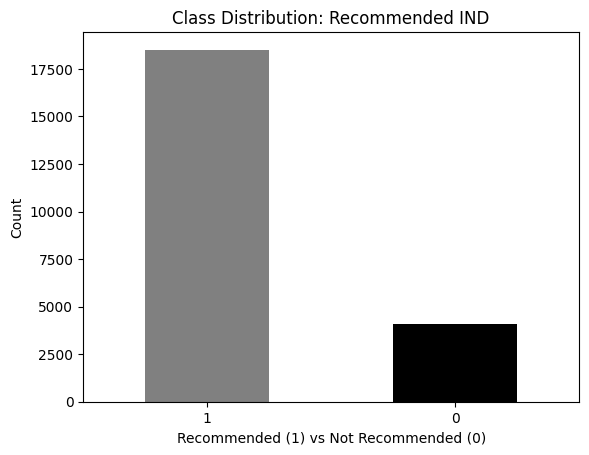

In [43]:
import matplotlib.pyplot as plt

df["Recommended IND"].value_counts().plot(kind='bar', color=['gray','black'])
plt.title("Class Distribution: Recommended IND")
plt.xlabel("Recommended (1) vs Not Recommended (0)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [44]:
y = df['Recommended IND']

In [45]:
categorical_columns = df_clean.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Title', 'Review Text', 'Division Name', 'Department Name',
       'Class Name'],
      dtype='object')


In [46]:
cat_feats = pd.get_dummies(
    df[['Division Name', 'Department Name', 'Class Name']],
    dummy_na=True
)
print(cat_feats.shape)

(22611, 32)


In [47]:
print("Embeddings shape:", X.shape)
print("Categorical features shape:", cat_feats.shape)

Embeddings shape: (22611, 384)
Categorical features shape: (22611, 32)


In [48]:
cat_feats = pd.get_dummies(
    df[['Division Name', 'Department Name', 'Class Name']],
    dummy_na=True,
    drop_first=True
).values
print(cat_feats.shape)

(22611, 29)


In [49]:
from sklearn.preprocessing import StandardScaler

numeric_feats = df[['Rating', 'Age', 'Positive Feedback Count']].values
numeric_feats_scaled = StandardScaler().fit_transform(numeric_feats)
print(numeric_feats_scaled.shape)

(22611, 3)


In [50]:
import numpy as np

X_combined = np.hstack([X, numeric_feats_scaled, cat_feats])
print("Combined feature shape:", X_combined.shape)

Combined feature shape: (22611, 416)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# ***Modeling Part***

**Imports**

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

**Logistic Regression**

In [53]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [54]:
lg_preds = log_reg.predict(X_test)
lg_probs = log_reg.predict_proba(X_test)[:, 1]

In [55]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, lg_preds))
print("ROC-AUC:", roc_auc_score(y_test, lg_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, lg_preds))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.75      0.94      0.84       820
           1       0.99      0.93      0.96      3703

    accuracy                           0.93      4523
   macro avg       0.87      0.94      0.90      4523
weighted avg       0.94      0.93      0.94      4523

ROC-AUC: 0.973089386983527
Confusion Matrix:
 [[ 772   48]
 [ 254 3449]]


In [56]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, lg_probs)
print("Log Loss:", loss)

Log Loss: 0.18851583922725307


Best threshold for class 0: 0.6901140322196331
Precision at best threshold: 0.7765306122448979
Recall at best threshold: 0.9280487804878049
F1 at best threshold: 0.8455555550595061


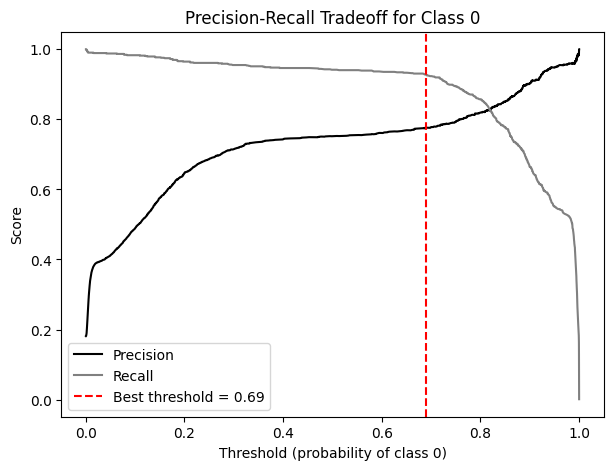

In [57]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

probs_class0 = 1 - lg_probs
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_class0, pos_label=0)

precisions_t = precisions[:-1]
recalls_t = recalls[:-1]

f1_scores = 2 * (precisions_t * recalls_t) / (precisions_t + recalls_t + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold for class 0:", best_threshold)
print("Precision at best threshold:", precisions_t[best_idx])
print("Recall at best threshold:", recalls_t[best_idx])
print("F1 at best threshold:", f1_scores[best_idx])

plt.figure(figsize=(7,5))
plt.plot(thresholds, precisions_t, label='Precision', color='black')
plt.plot(thresholds, recalls_t, label='Recall', color='gray')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold (probability of class 0)')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff for Class 0')
plt.legend()
plt.show()

In [58]:
# the classification report using the tuned threshold instead of the default 0.5
new_preds = np.where(probs_class0 >= best_threshold, 0, 1)

print("Logistic Regression Classiification Report using tuned threshold")
print(classification_report(y_test, new_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, new_preds))

Logistic Regression Classiification Report using tuned threshold
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       820
           1       0.98      0.94      0.96      3703

    accuracy                           0.94      4523
   macro avg       0.88      0.93      0.90      4523
weighted avg       0.95      0.94      0.94      4523

Confusion Matrix:
 [[ 761   59]
 [ 219 3484]]


In [59]:
from sklearn.metrics import accuracy_score

train_preds_final = log_reg.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_preds_final))
print("Test accuracy:", accuracy_score(y_test, lg_preds))

Train accuracy: 0.9363666519239274
Test accuracy: 0.9332301569754587


**Random Forest**

In [60]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [61]:
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [62]:
print("Random Forest Classification Report")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.90      0.41      0.57       820
           1       0.88      0.99      0.93      3703

    accuracy                           0.89      4523
   macro avg       0.89      0.70      0.75      4523
weighted avg       0.89      0.89      0.87      4523

ROC-AUC: 0.9661228865191702
Confusion Matrix:
 [[ 339  481]
 [  38 3665]]


**Tuned Random Forest**

In [63]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [8, 12, 16, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

In [64]:
rf_search = RandomizedSearchCV(
    rf_base, param_distributions=rf_param_dist,
    n_iter=20, scoring='f1', cv=3, random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [8, 12, 16, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 3, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1', verbose=1)

In [65]:
print("Best RF params:", rf_search.best_params_)
rf_tuned = rf_search.best_estimator_

Best RF params: {'n_estimators': 100, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 8}


In [66]:
rft_preds = rf_tuned.predict(X_test)
rft_probs = rf_tuned.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Classification Report")
print(classification_report(y_test, rft_preds))
print("ROC-AUC:", roc_auc_score(y_test, rft_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, rft_preds))

Tuned Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       820
           1       0.97      0.94      0.96      3703

    accuracy                           0.93      4523
   macro avg       0.87      0.90      0.88      4523
weighted avg       0.93      0.93      0.93      4523

ROC-AUC: 0.9603120080620196
Confusion Matrix:
 [[ 699  121]
 [ 205 3498]]


**XGBoost**

In [67]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [68]:
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [69]:
print("XGBoost Classification Report")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_preds))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.77      0.93      0.84       820
           1       0.98      0.94      0.96      3703

    accuracy                           0.94      4523
   macro avg       0.88      0.93      0.90      4523
weighted avg       0.95      0.94      0.94      4523

ROC-AUC: 0.9723796789682723
Confusion Matrix:
 [[ 763   57]
 [ 227 3476]]


**XGBoost Tuned**

In [70]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

In [71]:
xgb_base = XGBClassifier(
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    random_state=42
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',     # optimizes for F1 not accuracy bec of the class imbalance
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [72]:
print("Best XGBoost params:", xgb_search.best_params_)
print("Best CV F1 score:", xgb_search.best_score_)

xgb_tuned = xgb_search.best_estimator_

Best XGBoost params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV F1 score: 0.9614890508172653


In [73]:
xgbt_preds = xgb_tuned.predict(X_test)
xgbt_probs = xgb_tuned.predict_proba(X_test)[:, 1]

print("XGBoost tuned Classification Report")
print(classification_report(y_test, xgbt_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgbt_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgbt_preds))

XGBoost tuned Classification Report
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       820
           1       0.98      0.95      0.96      3703

    accuracy                           0.94      4523
   macro avg       0.88      0.93      0.91      4523
weighted avg       0.95      0.94      0.94      4523

ROC-AUC: 0.9738539285878952
Confusion Matrix:
 [[ 755   65]
 [ 203 3500]]


In [74]:
xgbt_train_preds = xgb_tuned.predict(X_train)
xgbt_test_preds = xgb_tuned.predict(X_test)
print("Train accuracy:", accuracy_score(y_train, xgbt_train_preds))
print("Test accuracy:", accuracy_score(y_test, xgbt_test_preds))

Train accuracy: 0.9986731534719151
Test accuracy: 0.9407472916206058


**Voting Ensemble (soft voting — averages probabilities)**

In [75]:
voting_ensemble = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf_tuned),
        ('xgb', xgb_tuned)
    ],
    voting='soft'
)

voting_ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=8,
                                                     min_samples_leaf=3,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.7, device=None,
                                            early_stopp...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [76]:
ve_preds = voting_ensemble.predict(X_test)
ve_probs = voting_ensemble.predict_proba(X_test)[:, 1]

In [77]:
print("Voting Ensemble Classification Report")
print(classification_report(y_test, ve_preds))
print("ROC-AUC:", roc_auc_score(y_test, ve_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, ve_preds))
print("Log Loss:", log_loss(y_test, ve_probs))

Voting Ensemble Classification Report
              precision    recall  f1-score   support

           0       0.77      0.93      0.84       820
           1       0.98      0.94      0.96      3703

    accuracy                           0.94      4523
   macro avg       0.88      0.94      0.90      4523
weighted avg       0.95      0.94      0.94      4523

ROC-AUC: 0.9734914999703601
Confusion Matrix:
 [[ 766   54]
 [ 234 3469]]
Log Loss: 0.20595183052463853


**Stacking Ensemble (meta-learner combines base model outputs)**

In [78]:
stacking_ensemble = StackingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf_tuned),
        ('xgb', xgb_tuned)
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=3
)

stacking_ensemble.fit(X_train, y_train)

StackingClassifier(cv=3,
                   estimators=[('lr',
                                LogisticRegression(class_weight='balanced',
                                                   max_iter=1000)),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=8,
                                                       min_samples_leaf=3,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.7, device=None,
                                              earl...
                                              interaction_constraints=None,
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=8,
                                              max_leaves=None,
                                              min_child_weight=1, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=300, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000))

In [79]:
se_preds = stacking_ensemble.predict(X_test)
se_probs = stacking_ensemble.predict_proba(X_test)[:, 1]

In [80]:
print("Stacking Ensemble Classification Report")
print(classification_report(y_test, se_preds))
print("ROC-AUC:", roc_auc_score(y_test, se_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, se_preds))
print("Log Loss:", log_loss(y_test, se_probs))

Stacking Ensemble Classification Report
              precision    recall  f1-score   support

           0       0.75      0.94      0.84       820
           1       0.99      0.93      0.96      3703

    accuracy                           0.93      4523
   macro avg       0.87      0.94      0.90      4523
weighted avg       0.94      0.93      0.94      4523

ROC-AUC: 0.9732688723052503
Confusion Matrix:
 [[ 773   47]
 [ 253 3450]]
Log Loss: 0.19971684519489033


**Check overfitting**

In [81]:
ve_train_preds = voting_ensemble.predict(X_train)
print("Voting Ensemble - Train accuracy:", accuracy_score(y_train, ve_train_preds))
print("Voting Ensemble - Test accuracy:", accuracy_score(y_test, ve_preds))

se_train_preds = stacking_ensemble.predict(X_train)
print("Stacking Ensemble - Train accuracy:", accuracy_score(y_train, se_train_preds))
print("Stacking Ensemble - Test accuracy:", accuracy_score(y_test, se_preds))

Voting Ensemble - Train accuracy: 0.9668841220698806
Voting Ensemble - Test accuracy: 0.9363254477116958
Stacking Ensemble - Train accuracy: 0.9363113666519239
Stacking Ensemble - Test accuracy: 0.9336723413663498


# **Models comparison**

In [94]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss

models_results = {
    "Logistic Regression": (log_reg, lg_preds, lg_probs),
    "Logistic Regression (tuned threshold)": (log_reg, new_preds, lg_probs),
    "Random Forest (default)": (rf, rf_preds, rf_probs),
    "Random Forest (tuned)": (rf_tuned, rft_preds, rft_probs),
    "XGBoost (default)": (xgb, xgb_preds, xgb_probs),
    "XGBoost (tuned)": (xgb_tuned, xgbt_preds, xgbt_probs),
    "Voting Ensemble": (voting_ensemble, ve_preds, ve_probs),
    "Stacking Ensemble": (stacking_ensemble, se_preds, se_probs),
}

rows = []
for name, (model, preds, probs) in models_results.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (class 0)": precision_score(y_test, preds, pos_label=0),
        "Recall (class 0)": recall_score(y_test, preds, pos_label=0),
        "F1 (class 0)": f1_score(y_test, preds, pos_label=0),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "Log Loss": log_loss(y_test, probs),
    })

comparison_df = pd.DataFrame(rows).sort_values("F1 (class 0)", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision (class 0),Recall (class 0),F1 (class 0),ROC-AUC,Log Loss
0,XGBoost (tuned),0.940747,0.788100,0.920732,0.849269,0.973854,0.158107
1,Logistic Regression (tuned threshold),0.938536,0.776531,0.928049,0.845556,0.973089,0.188516
2,XGBoost (default),0.937210,0.770707,0.930488,0.843094,0.972380,0.165585
3,Voting Ensemble,0.936325,0.766000,0.934146,0.841758,0.973491,0.205952
4,Stacking Ensemble,0.933672,0.753411,0.942683,0.837486,0.973269,0.199717
5,Logistic Regression,0.933230,0.752437,0.941463,0.836403,0.973089,0.188516
6,Random Forest (tuned),0.927924,0.773230,0.852439,0.810905,0.960312,0.361938
7,Random Forest (default),0.885253,0.899204,0.413415,0.566416,0.966123,0.240981


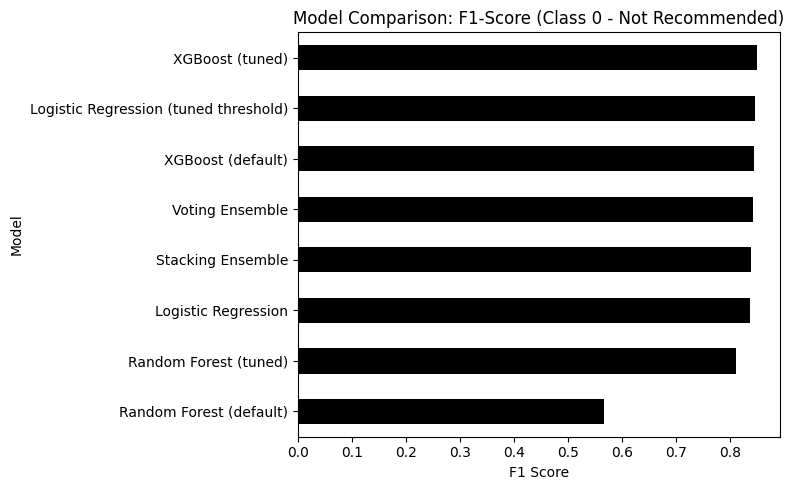

In [95]:
comparison_df.set_index("Model")["F1 (class 0)"].sort_values().plot(
    kind='barh', color='black', figsize=(8,5)
)
plt.title("Model Comparison: F1-Score (Class 0 - Not Recommended)")
plt.xlabel("F1 Score")
plt.tight_layout()
plt.show()

# **K-Means Clustering**

Explained variance retained: 0.6483102


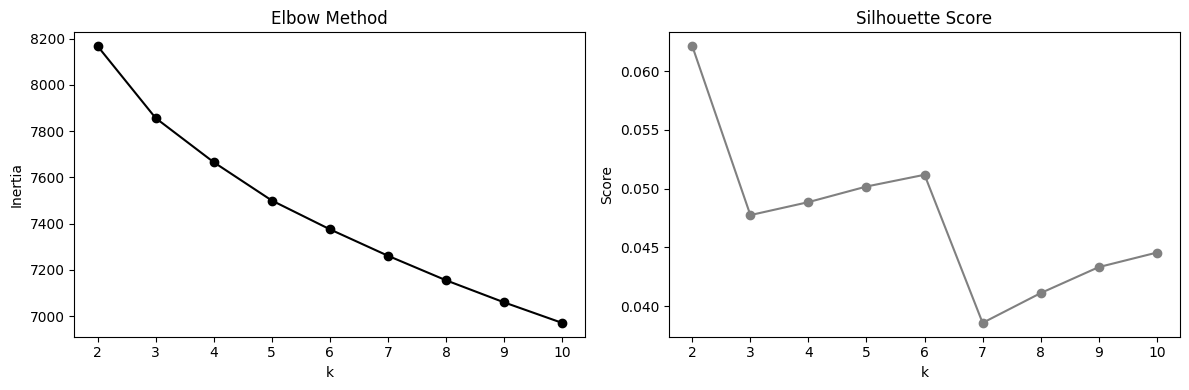

In [82]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_reduce = PCA(n_components=50, random_state=42)
X_reduced = pca_reduce.fit_transform(X)
print("Explained variance retained:", pca_reduce.explained_variance_ratio_.sum())

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_reduced)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_reduced, km.labels_, sample_size=3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(K_range, inertia, marker='o', color='black')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(K_range, silhouette_scores, marker='o', color='gray')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

In [83]:
best_k = 6
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_reduced)

print(df['Cluster'].value_counts())

Cluster
5    5015
3    5006
2    3435
4    3333
0    2960
1    2862
Name: count, dtype: int64


In [84]:
from sklearn.feature_extraction.text import CountVectorizer

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_text = df[df['Cluster'] == cluster_id]['Clean_Review']
    cv = CountVectorizer(stop_words='english', max_features=15)
    cv.fit(cluster_text)
    print(f"Cluster {cluster_id} ({(df['Cluster']==cluster_id).sum()} reviews) top words:")
    print(list(cv.get_feature_names_out()))
    print()

Cluster 0 (2960 reviews) top words:
['beautiful', 'color', 'cute', 'fabric', 'fit', 'flattering', 'great', 'im', 'like', 'little', 'look', 'love', 'really', 'size', 'wear']

Cluster 1 (2862 reviews) top words:
['color', 'comfortable', 'fit', 'great', 'im', 'jean', 'like', 'look', 'love', 'pair', 'pant', 'perfect', 'size', 'waist', 'wear']

Cluster 2 (3435 reviews) top words:
['color', 'fabric', 'fit', 'great', 'like', 'little', 'look', 'love', 'material', 'really', 'shirt', 'sleeve', 'soft', 'sweater', 'wear']

Cluster 3 (5006 reviews) top words:
['beautiful', 'color', 'dress', 'fabric', 'fit', 'flattering', 'great', 'im', 'like', 'look', 'love', 'perfect', 'size', 'skirt', 'wear']

Cluster 4 (3333 reviews) top words:
['black', 'bought', 'color', 'fabric', 'fit', 'great', 'im', 'like', 'look', 'love', 'ordered', 'really', 'shirt', 'soft', 'wear']

Cluster 5 (5015 reviews) top words:
['color', 'dress', 'fit', 'great', 'im', 'large', 'like', 'little', 'look', 'love', 'medium', 'ordered',

# **Visualizations**

**Most common words**

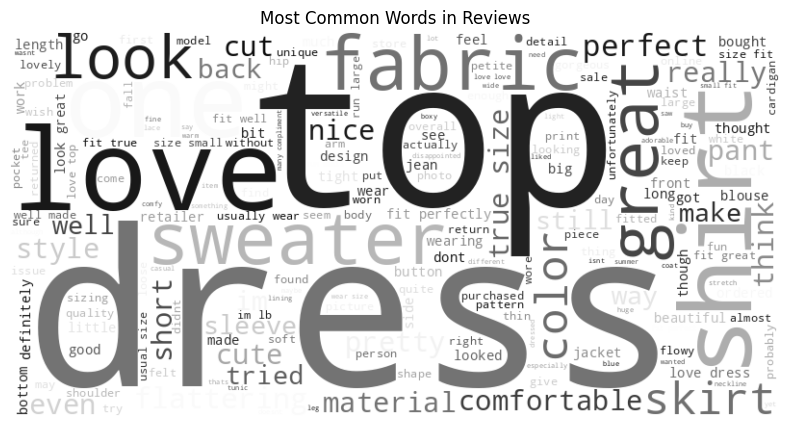

In [85]:
from wordcloud import WordCloud

text = " ".join(df['Clean_Review'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='gray').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Reviews")
plt.show()

**Rating distribution**

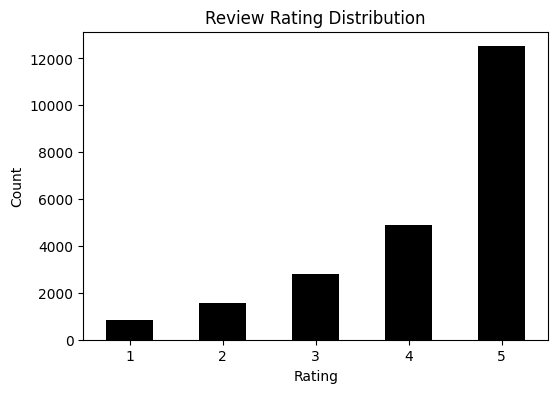

In [86]:
plt.figure(figsize=(6,4))
df['Rating'].value_counts().sort_index().plot(kind='bar', color='black')
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Cluster analysis (2D visualization via PCA)**

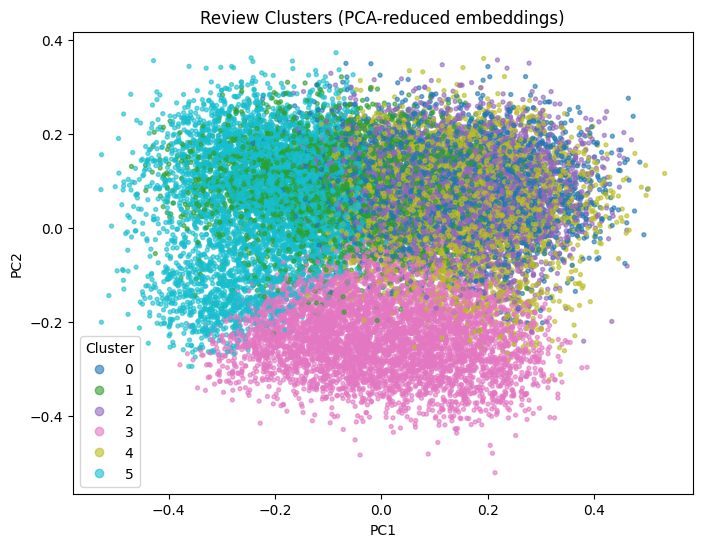

In [87]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='tab10', s=8, alpha=0.6)
plt.title("Review Clusters (PCA-reduced embeddings)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

**Cluster vs. recommendation rate**

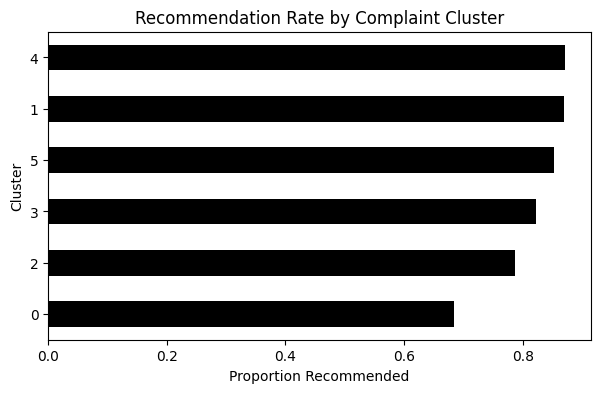

In [88]:
cluster_summary = df.groupby('Cluster')['Recommended IND'].mean().sort_values()
cluster_summary.plot(kind='barh', color='black', figsize=(7,4))
plt.title("Recommendation Rate by Complaint Cluster")
plt.xlabel("Proportion Recommended")
plt.show()

**SHAP on TF-IDF + Logistic Regression**

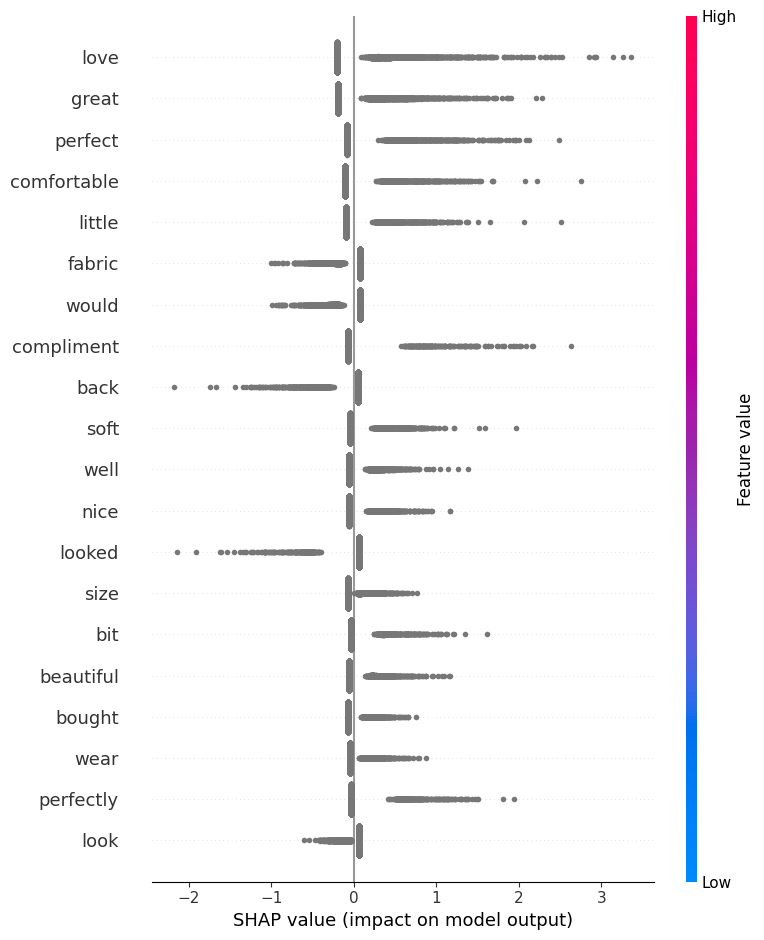

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import shap

tfidf = TfidfVectorizer(max_features=500)
X_tfidf = tfidf.fit_transform(df['Clean_Review'])

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

lr_interp = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_interp.fit(Xt_train, yt_train)

explainer = shap.LinearExplainer(lr_interp, Xt_train)
shap_values = explainer(Xt_test)

shap.summary_plot(shap_values, Xt_test, feature_names=tfidf.get_feature_names_out())

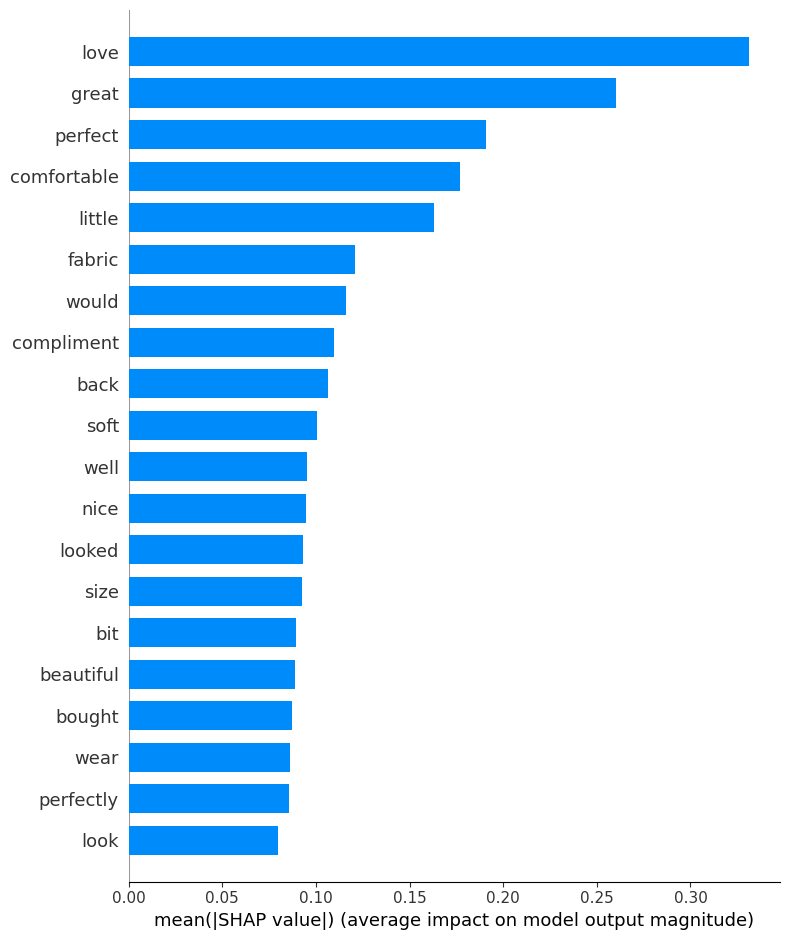

In [90]:
shap.summary_plot(shap_values, Xt_test, feature_names=tfidf.get_feature_names_out(), plot_type='bar')

**Permutation Importance**

Rating       0.140403
embed_259    0.001125
embed_263    0.001101
embed_64     0.000832
embed_299    0.000829
embed_33     0.000768
embed_152    0.000751
embed_78     0.000744
embed_330    0.000744
embed_61     0.000738
embed_195    0.000733
embed_40     0.000720
embed_200    0.000715
embed_26     0.000678
embed_309    0.000670
dtype: float64


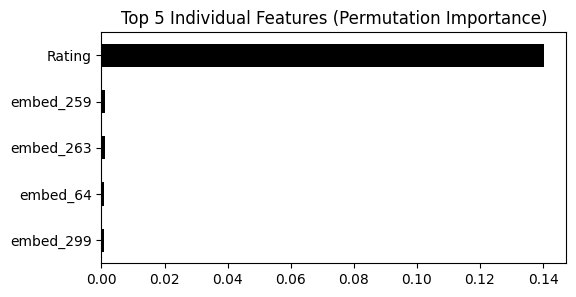

In [91]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    xgb_tuned, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1'
)

feature_names = (
    ['embed_' + str(i) for i in range(X.shape[1])] +
    ['Rating', 'Age', 'Positive Feedback Count'] +
    list(pd.get_dummies(df[['Division Name','Department Name','Class Name']], dummy_na=True, drop_first=True).columns)
)

import pandas as pd
importances = pd.Series(result.importances_mean, index=feature_names).sort_values(ascending=False)
print(importances.head(15))

importances.head(5).plot(kind='barh', color='black', figsize=(6,3))
plt.title("Top 5 Individual Features (Permutation Importance)")
plt.gca().invert_yaxis()
plt.show()

Embeddings (as a group) importance: 0.035726575909721524
Structured features (as a group) importance: 0.6382832722641463


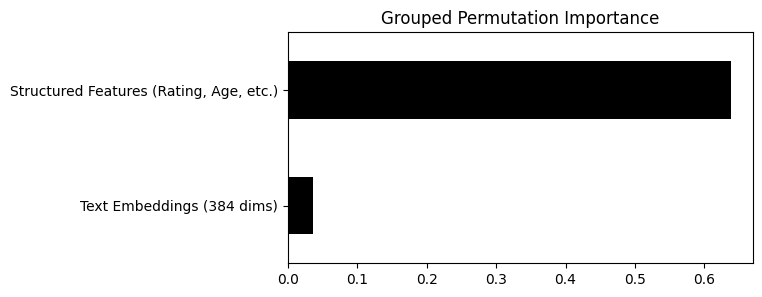

In [92]:
import numpy as np
from sklearn.metrics import f1_score

embed_idx = list(range(0, X.shape[1]))
structured_idx = list(range(X.shape[1], X_combined.shape[1]))

def group_permutation_importance(model, X_test, y_test, group_idx, n_repeats=5):
    baseline_score = f1_score(y_test, model.predict(X_test), pos_label=0)
    scores = []
    for _ in range(n_repeats):
        X_test_permuted = X_test.copy()
        rng = np.random.default_rng()
        for col in group_idx:
            X_test_permuted[:, col] = rng.permutation(X_test_permuted[:, col])
        permuted_score = f1_score(y_test, model.predict(X_test_permuted), pos_label=0)
        scores.append(baseline_score - permuted_score)
    return np.mean(scores)

embed_importance = group_permutation_importance(xgb_tuned, X_test, y_test, embed_idx)
structured_importance = group_permutation_importance(xgb_tuned, X_test, y_test, structured_idx)

print("Embeddings (as a group) importance:", embed_importance)
print("Structured features (as a group) importance:", structured_importance)

pd.Series(
    {"Text Embeddings (384 dims)": embed_importance, "Structured Features (Rating, Age, etc.)": structured_importance}
).plot(kind='barh', color='black', figsize=(6,3))
plt.title("Grouped Permutation Importance")
plt.show()

**LIME**

In [93]:
!pip install lime -q
from lime.lime_text import LimeTextExplainer

explainer_lime = LimeTextExplainer(class_names=['Not Recommended', 'Recommended'])

idx = 5
sample_text = df['Clean_Review'].iloc[idx]

def predict_fn(texts):
    vecs = tfidf.transform(texts)
    return lr_interp.predict_proba(vecs)

exp = explainer_lime.explain_instance(sample_text, predict_fn, num_features=10)
exp.show_in_notebook(text=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
